In [152]:
import pandas as pd
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from textblob import Word
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import joblib
import numpy as np
import re


# Downloading necessary NLTK datasets
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


#Importing Dataset

In [2]:
df = pd.read_csv("/content/sample_data/IMDB Dataset.csv")

In [46]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
text = df['review'][2]
text

'I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I\'d laughed at one of Woody\'s comedies in years (dare I say a decade?). While I\'ve never been impressed with Scarlet Johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than "Devil Wears Prada" and more interesting than "Superman" a great comedy to go see with friends.'

# Data PreProcessing

### Lowercasing the Data

In [12]:
lowered_text = text.lower()
lowered_text

'i thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. the plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). while some may be disappointed when they realize this is not match point 2: risk addiction, i thought it was proof that woody allen is still fully in control of the style many of us have grown to love.<br /><br />this was the most i\'d laughed at one of woody\'s comedies in years (dare i say a decade?). while i\'ve never been impressed with scarlet johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />this may not be the crown jewel of his career, but it was wittier than "devil wears prada" and more interesting than "superman" a great comedy to go see with friends.'

### Removing Punctuation

In [15]:
punctuation_removed = ''.join(filter(lambda x: x.isalpha() or x.isdigit() or x.isspace(), lowered_text))
punctuation_removed

'i thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air conditioned theater and watching a lighthearted comedy the plot is simplistic but the dialogue is witty and the characters are likable even the well bread suspected serial killer while some may be disappointed when they realize this is not match point 2 risk addiction i thought it was proof that woody allen is still fully in control of the style many of us have grown to lovebr br this was the most id laughed at one of woodys comedies in years dare i say a decade while ive never been impressed with scarlet johanson in this she managed to tone down her sexy image and jumped right into a average but spirited young womanbr br this may not be the crown jewel of his career but it was wittier than devil wears prada and more interesting than superman a great comedy to go see with friends'

### Tokenization

In [17]:
tokenized_text = word_tokenize(punctuation_removed)
print(tokenized_text)

['i', 'thought', 'this', 'was', 'a', 'wonderful', 'way', 'to', 'spend', 'time', 'on', 'a', 'too', 'hot', 'summer', 'weekend', 'sitting', 'in', 'the', 'air', 'conditioned', 'theater', 'and', 'watching', 'a', 'lighthearted', 'comedy', 'the', 'plot', 'is', 'simplistic', 'but', 'the', 'dialogue', 'is', 'witty', 'and', 'the', 'characters', 'are', 'likable', 'even', 'the', 'well', 'bread', 'suspected', 'serial', 'killer', 'while', 'some', 'may', 'be', 'disappointed', 'when', 'they', 'realize', 'this', 'is', 'not', 'match', 'point', '2', 'risk', 'addiction', 'i', 'thought', 'it', 'was', 'proof', 'that', 'woody', 'allen', 'is', 'still', 'fully', 'in', 'control', 'of', 'the', 'style', 'many', 'of', 'us', 'have', 'grown', 'to', 'lovebr', 'br', 'this', 'was', 'the', 'most', 'id', 'laughed', 'at', 'one', 'of', 'woodys', 'comedies', 'in', 'years', 'dare', 'i', 'say', 'a', 'decade', 'while', 'ive', 'never', 'been', 'impressed', 'with', 'scarlet', 'johanson', 'in', 'this', 'she', 'managed', 'to', 'to

### Stop Words Removal

In [21]:
stop_words = set(stopwords.words('english'))
Removed_text = [w for w in tokenized_text if not w in stop_words]
# Removed_text = " ".join(Removed_text)
print(Removed_text)

['thought', 'wonderful', 'way', 'spend', 'time', 'hot', 'summer', 'weekend', 'sitting', 'air', 'conditioned', 'theater', 'watching', 'lighthearted', 'comedy', 'plot', 'simplistic', 'dialogue', 'witty', 'characters', 'likable', 'even', 'well', 'bread', 'suspected', 'serial', 'killer', 'may', 'disappointed', 'realize', 'match', 'point', '2', 'risk', 'addiction', 'thought', 'proof', 'woody', 'allen', 'still', 'fully', 'control', 'style', 'many', 'us', 'grown', 'lovebr', 'br', 'id', 'laughed', 'one', 'woodys', 'comedies', 'years', 'dare', 'say', 'decade', 'ive', 'never', 'impressed', 'scarlet', 'johanson', 'managed', 'tone', 'sexy', 'image', 'jumped', 'right', 'average', 'spirited', 'young', 'womanbr', 'br', 'may', 'crown', 'jewel', 'career', 'wittier', 'devil', 'wears', 'prada', 'interesting', 'superman', 'great', 'comedy', 'go', 'see', 'friends']


### Parts Of Speech Tagging

In [31]:
Tagged_Words = pos_tag(Removed_text)
Tagged_Words

[('thought', 'VBN'),
 ('wonderful', 'JJ'),
 ('way', 'NN'),
 ('spend', 'JJ'),
 ('time', 'NN'),
 ('hot', 'JJ'),
 ('summer', 'NN'),
 ('weekend', 'NN'),
 ('sitting', 'VBG'),
 ('air', 'NN'),
 ('conditioned', 'VBN'),
 ('theater', 'NN'),
 ('watching', 'VBG'),
 ('lighthearted', 'JJ'),
 ('comedy', 'NN'),
 ('plot', 'NN'),
 ('simplistic', 'JJ'),
 ('dialogue', 'NN'),
 ('witty', 'NN'),
 ('characters', 'NNS'),
 ('likable', 'JJ'),
 ('even', 'RB'),
 ('well', 'RB'),
 ('bread', 'RB'),
 ('suspected', 'VBN'),
 ('serial', 'JJ'),
 ('killer', 'NN'),
 ('may', 'MD'),
 ('disappointed', 'VB'),
 ('realize', 'VB'),
 ('match', 'NN'),
 ('point', 'NN'),
 ('2', 'CD'),
 ('risk', 'NN'),
 ('addiction', 'NN'),
 ('thought', 'VBD'),
 ('proof', 'NN'),
 ('woody', 'NN'),
 ('allen', 'NN'),
 ('still', 'RB'),
 ('fully', 'RB'),
 ('control', 'VB'),
 ('style', 'NN'),
 ('many', 'JJ'),
 ('us', 'PRP'),
 ('grown', 'JJ'),
 ('lovebr', 'JJ'),
 ('br', 'NN'),
 ('id', 'NN'),
 ('laughed', 'VBD'),
 ('one', 'CD'),
 ('woodys', 'NN'),
 ('comedies'

In [32]:
# Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

### Lemmatization

In [43]:
lemmatized_tokens = []
lemmatizer = WordNetLemmatizer()
for token, tag in Tagged_Words:
    wordnet_pos = get_wordnet_pos(tag)
    # Lemmatize the word with the correct POS tag
    lemmatized_word = lemmatizer.lemmatize(token, wordnet_pos)
    lemmatized_tokens.append(lemmatized_word)

print(lemmatized_tokens)

['think', 'wonderful', 'way', 'spend', 'time', 'hot', 'summer', 'weekend', 'sit', 'air', 'condition', 'theater', 'watch', 'lighthearted', 'comedy', 'plot', 'simplistic', 'dialogue', 'witty', 'character', 'likable', 'even', 'well', 'bread', 'suspect', 'serial', 'killer', 'may', 'disappoint', 'realize', 'match', 'point', '2', 'risk', 'addiction', 'think', 'proof', 'woody', 'allen', 'still', 'fully', 'control', 'style', 'many', 'u', 'grown', 'lovebr', 'br', 'id', 'laugh', 'one', 'woodys', 'comedy', 'year', 'dare', 'say', 'decade', 'ive', 'never', 'impressed', 'scarlet', 'johanson', 'manage', 'tone', 'sexy', 'image', 'jump', 'right', 'average', 'spirit', 'young', 'womanbr', 'br', 'may', 'crown', 'jewel', 'career', 'witty', 'devil', 'wear', 'prada', 'interest', 'superman', 'great', 'comedy', 'go', 'see', 'friend']


### Spelling Correction

In [44]:
corrected_spellings = [Word(token).correct() for token in lemmatized_tokens]
print(corrected_spellings)

['think', 'wonderful', 'way', 'spend', 'time', 'hot', 'summer', 'weekend', 'sit', 'air', 'condition', 'theater', 'watch', 'lighthearted', 'comedy', 'plot', 'simplistic', 'dialogue', 'witty', 'character', 'liable', 'even', 'well', 'bread', 'suspect', 'aerial', 'killer', 'may', 'disappoint', 'realize', 'match', 'point', '2', 'risk', 'addition', 'think', 'proof', 'wood', 'allen', 'still', 'fully', 'control', 'style', 'many', 'u', 'grown', 'lover', 'br', 'id', 'laugh', 'one', 'woods', 'comedy', 'year', 'dare', 'say', 'decade', 'give', 'never', 'impressed', 'scarlet', 'johnson', 'manage', 'tone', 'sex', 'image', 'jump', 'right', 'average', 'spirit', 'young', 'woman', 'br', 'may', 'crown', 'jewel', 'career', 'witty', 'devil', 'wear', 'trade', 'interest', 'sherman', 'great', 'comedy', 'go', 'see', 'friend']


Now, we have gone through all the preprocessing steps to be applied. Let's create a function for all.

In [83]:
global count
count = 0
def preprocess(text):
  # Lowering the data
  lowered_text = text.lower()
  # Removing Punctuation
  punctuation_removed = ''.join(filter(lambda x: x.isalpha() or x.isdigit() or x.isspace(), lowered_text))
  # Tokenization
  tokenized_text = word_tokenize(punctuation_removed)
  # Stop Words removal
  Removed_text = [w for w in tokenized_text if not w in stop_words]
  # POS Tagging
  Tagged_Words = pos_tag(Removed_text)
  # Lemmatization
  lemmatized_tokens = []
  lemmatizer = WordNetLemmatizer()
  for token, tag in Tagged_Words:
    wordnet_pos = get_wordnet_pos(tag)
    # Lemmatize the word with the correct POS tag
    lemmatized_word = lemmatizer.lemmatize(token, wordnet_pos)
    lemmatized_tokens.append(lemmatized_word)
  # Spelling Correction
  corrected_spellings = [Word(token).correct() for token in lemmatized_tokens]
  global count
  count += 1
  if count%100==0:
    print(count, "Done.")
  return corrected_spellings

# Data Inspection

Let's review the dataset to handle any imbalances



In [56]:
value_count = df['sentiment'].value_counts()
value_count

,count
sentiment,
positive,25000
negative,25000


The data is perfectly balanced between the negative and positive sentiments. We can visualize it through a bar chart too.

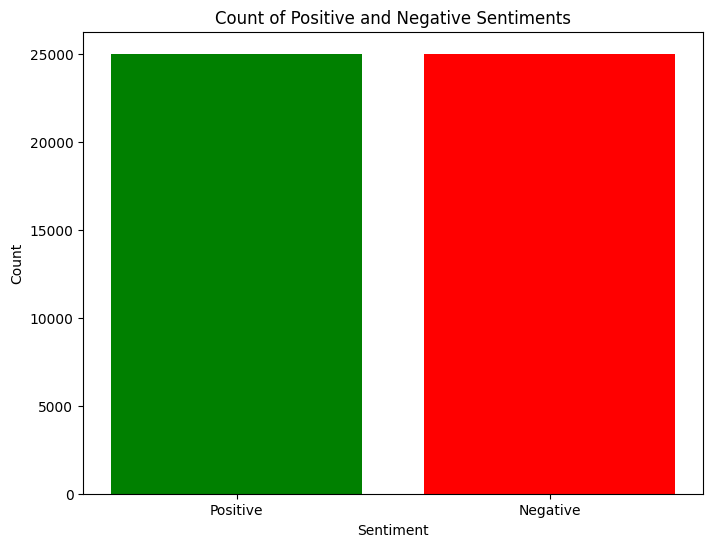

In [57]:
import matplotlib.pyplot as plt

# Sample data
sentiment_counts = {
    'Positive': value_count.iloc[0],  # Replace with your actual count
    'Negative': value_count.iloc[1]    # Replace with your actual count
}

# Extracting labels and values
labels = list(sentiment_counts.keys())
values = list(sentiment_counts.values())

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=['green', 'red'])

# Adding titles and labels
plt.title('Count of Positive and Negative Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')

# Display the plot
plt.show()

### Mapping the Sentiment

In [60]:
df['Sentiment_Numeric'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
df.head(5)

,review,sentiment,Sentiment_Numeric
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [63]:
df1 = df.drop(["sentiment"], axis=1)
df1.head(5)

,review,Sentiment_Numeric
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


### Preprocessing the whole Dataset

In [78]:
movie_df = df1[:1000]

In [84]:
movie_df['review'] = movie_df['review'].apply(preprocess)

100 Done.
200 Done.
300 Done.
400 Done.
500 Done.
600 Done.
700 Done.
800 Done.
900 Done.
1000 Done.


<ipython-input-84-997f93a1c3a6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_df['review'] = movie_df['review'].apply(preprocess)


# TF-IDF and Word Embedding

In [86]:
X = movie_df['review']
y = movie_df['Sentiment_Numeric']
X

,review
0,"[one, reviewed, mention, watch, 1, oz, episode..."
1,"[wonderful, little, production, br, br, film, ..."
2,"[think, wonderful, way, spend, time, hot, summ..."
3,"[basically, there, family, little, boy, jake, ..."
4,"[letter, matters, love, time, money, usually, ..."
...,...
995,"[nothing, sacred, ask, erie, fosselius, day, e..."
996,"[hat, hate, delaware, pretensions, insanity, m..."
997,"[usually, try, professional, constructive, cri..."
998,"[like, go, see, film, history, class, somethin..."


### TF-IDF

In [121]:
# Convert the array of tokens back into strings
movie_df['text'] = movie_df['review'].apply(lambda tokens: ' '.join(tokens))

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the text data to a TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(movie_df['text'])

# Convert the TF-IDF matrix to a DataFrame for easy use
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())


<ipython-input-121-a3e67f901467>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_df['text'] = movie_df['review'].apply(lambda tokens: ' '.join(tokens))


In [122]:
X_train1,X_test1,y_train1,y_test1 = train_test_split(tfidf_df,y, test_size=0.2,random_state=42)

### Word2Vec

In [115]:
# Step 1: Train Word2Vec on the tokenized reviews
word2vec_model = Word2Vec(sentences=movie_df['review'], vector_size=50)

# Step 2: Function to create document vectors by averaging word vectors
def vectorize_review(review, model):
    # Only keep vectors for words that exist in the Word2Vec model
    vectors = [model.wv[word] for word in review if word in model.wv]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(50)  # 50 is vector_size

# Apply the vectorization to all reviews
movie_df['review_vector'] = movie_df['review'].apply(lambda review: vectorize_review(review, word2vec_model))

# Convert the list of vectors into a DataFrame
X = pd.DataFrame(movie_df['review_vector'].to_list())
y = movie_df['Sentiment_Numeric']

# Step 3: Split the data into train and test sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)


<ipython-input-115-93bfa0cd5763>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_df['review_vector'] = movie_df['review'].apply(lambda review: vectorize_review(review, word2vec_model))


# Applying Model

### Using Word2Vec

In [132]:
# Scale the features to the range [0, 1]
scaler = MinMaxScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)  # Use the same scaling as the training data


In [133]:
nlp_model = MultinomialNB()

nlp_model.fit(X_train2_scaled,y_train2)
y_pred2 = nlp_model.predict(X_test2_scaled)

accuracy = accuracy_score(y_test2, y_pred2)
classification_rep = classification_report(y_test2, y_pred2)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{classification_rep}")

Accuracy: 0.53
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.53      0.54       104
           1       0.51      0.53      0.52        96

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.53      0.53      0.53       200



In [135]:
log_reg = LogisticRegression()

log_reg.fit(X_train2, y_train2)

y_pred = log_reg.predict(X_test2)

accuracy = accuracy_score(y_test2, y_pred)
classification_rep = classification_report(y_test2, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{classification_rep}")


Accuracy: 0.535
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.49      0.52       104
           1       0.51      0.58      0.55        96

    accuracy                           0.54       200
   macro avg       0.54      0.54      0.53       200
weighted avg       0.54      0.54      0.53       200



Using Word2Vec model, the MultimonialNB and logistic Regression has achieved an accuracy of 53% which are pretty low. Lwt's try TF-IDF.

### Using TF_IDF

In [140]:
# Scale the features to the range [0, 1]
scaler = MinMaxScaler()
scaler_model = scaler.fit(X_train1)
X_train1_scaled = scaler.transform(X_train1)
X_test1_scaled = scaler.transform(X_test1)  # Use the same scaling as the training data


In [141]:
nlp_model = MultinomialNB()

nlp_model.fit(X_train1_scaled,y_train1)
y_pred1 = nlp_model.predict(X_test1_scaled)

accuracy = accuracy_score(y_test1, y_pred1)
classification_rep = classification_report(y_test1, y_pred1)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{classification_rep}")

Accuracy: 0.76
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       104
           1       0.78      0.70      0.74        96

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.76      0.76       200



In [142]:
log_reg = LogisticRegression()

log_reg.fit(X_train1, y_train1)

y_pred = log_reg.predict(X_test1)

accuracy = accuracy_score(y_test2, y_pred)
classification_rep = classification_report(y_test1, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{classification_rep}")


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       104
           1       0.81      0.88      0.84        96

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



Using TF-IDF model, the MultimonialNB has achiebed an accuracy of 76% and logistic Regression has achieved an accuracy of 84% which are comaratively much higher.

# Hyper Parameter Tuning

In [145]:

log_reg = LogisticRegression()

# Set up the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],         # Type of regularization
    'solver': ['liblinear', 'lbfgs'] # Optimization algorithm
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid,
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train1, y_train1)

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score}")

# Use the best model to make predictions on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test1)

# Evaluate the model
accuracy = accuracy_score(y_test1, y_pred)
classification_rep = classification_report(y_test1, y_pred)

print(f"Test Accuracy: {accuracy}")
print(f"Classification Report:\n{classification_rep}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
25 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1169, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/u

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.8162499999999999
Test Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       104
           1       0.84      0.84      0.84        96

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



After hyperparameter Tuning, the model has achieved an accuracy of upto 85%.

# Saving the Model

In [147]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

# Prediction


In [150]:
def prediction(text):
  text = preprocess(text)
  text = tfidf_vectorizer.transform(text)
  prediction = best_model.predict(text)
  if prediction[0] == 1:
    return "Positive"
  else:
    return "Negative"

In [153]:
prediction("Nice Movie")

'Positive'

In [154]:
prediction("Hilarious. I have never seen such a great movie.")

'Positive'

In [155]:
prediction("Who makes such movies?")

'Negative'